Train shape: (440833, 12)
Test shape: (64374, 12)

Train columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Missing values in train:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Missing values in test:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


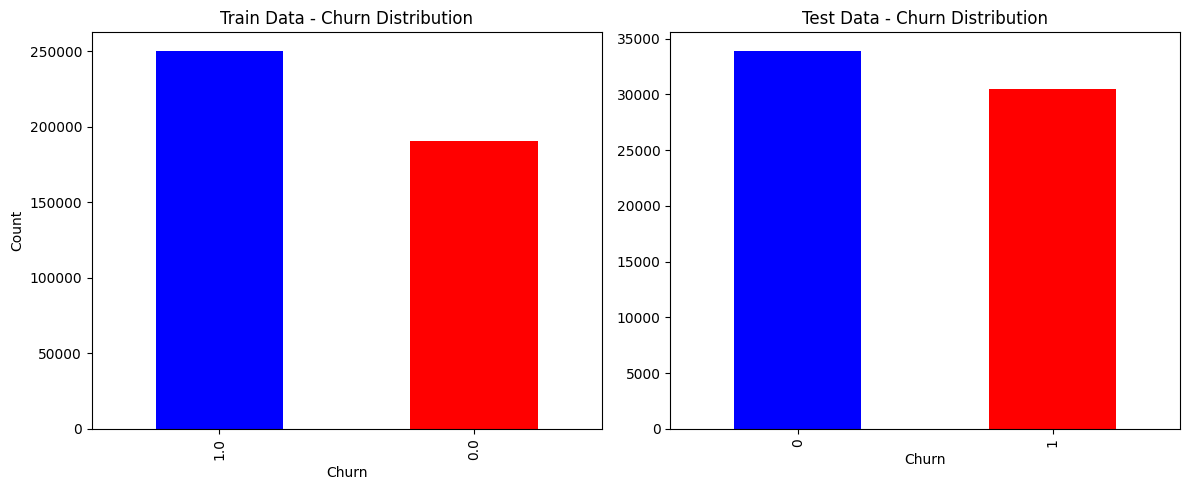

Train data statistics:
          CustomerID            Age         Tenure  Usage Frequency  \
count  440832.000000  440832.000000  440832.000000    440832.000000   
mean   225398.667955      39.373153      31.256336        15.807494   
std    129531.918550      12.442369      17.255727         8.586242   
min         2.000000      18.000000       1.000000         1.000000   
25%    113621.750000      29.000000      16.000000         9.000000   
50%    226125.500000      39.000000      32.000000        16.000000   
75%    337739.250000      48.000000      46.000000        23.000000   
max    449999.000000      65.000000      60.000000        30.000000   

       Support Calls  Payment Delay    Total Spend  Last Interaction  \
count  440832.000000  440832.000000  440832.000000     440832.000000   
mean        3.604437      12.965722     631.616223         14.480868   
std         3.070218       8.258063     240.803001          8.596208   
min         0.000000       0.000000     100.00000

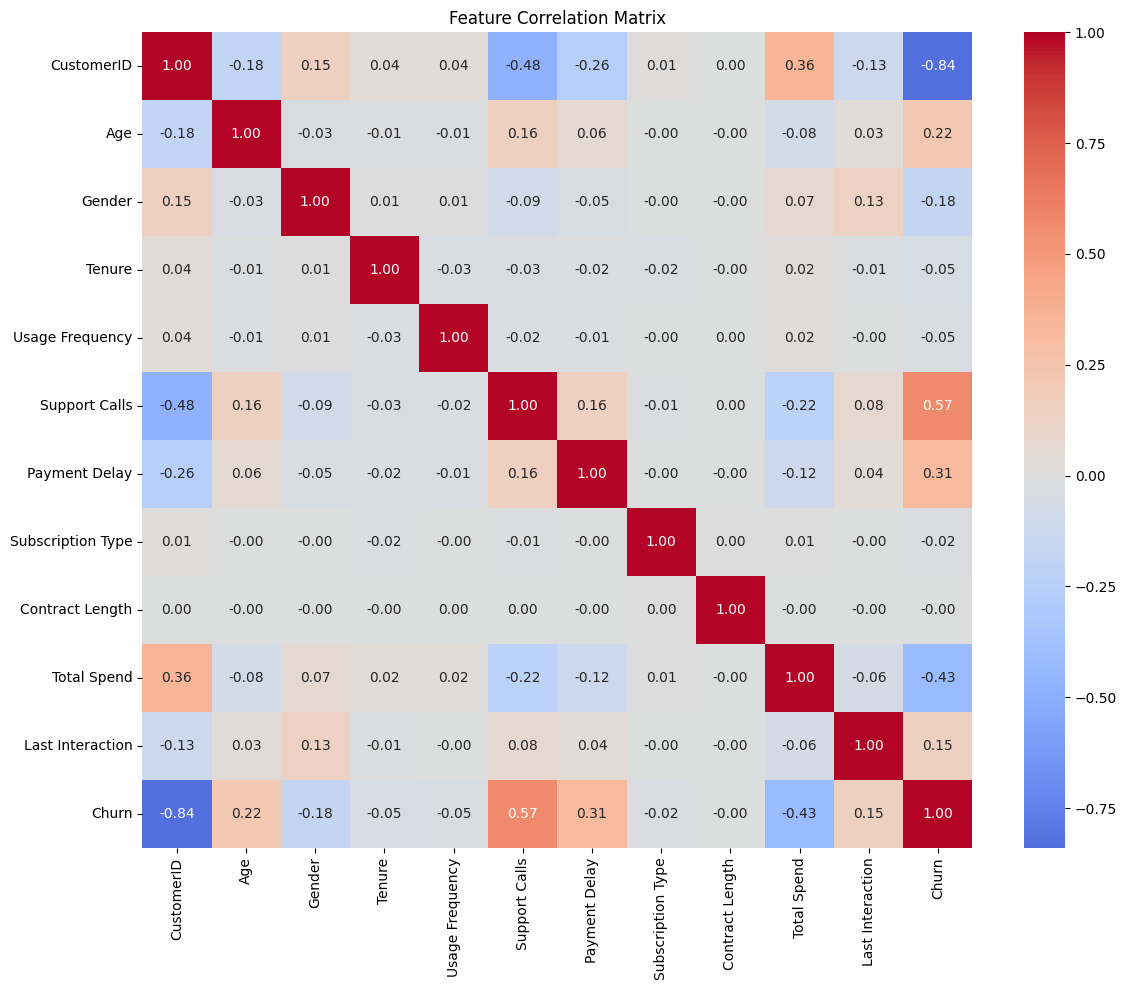

Correlation with Churn:
Churn                1.000000
Support Calls        0.574267
Payment Delay        0.312129
Age                  0.218394
Last Interaction     0.149616
Contract Length     -0.000093
Subscription Type   -0.017181
Usage Frequency     -0.046101
Tenure              -0.051919
Gender              -0.175395
Total Spend         -0.429355
CustomerID          -0.839365
Name: Churn, dtype: float64


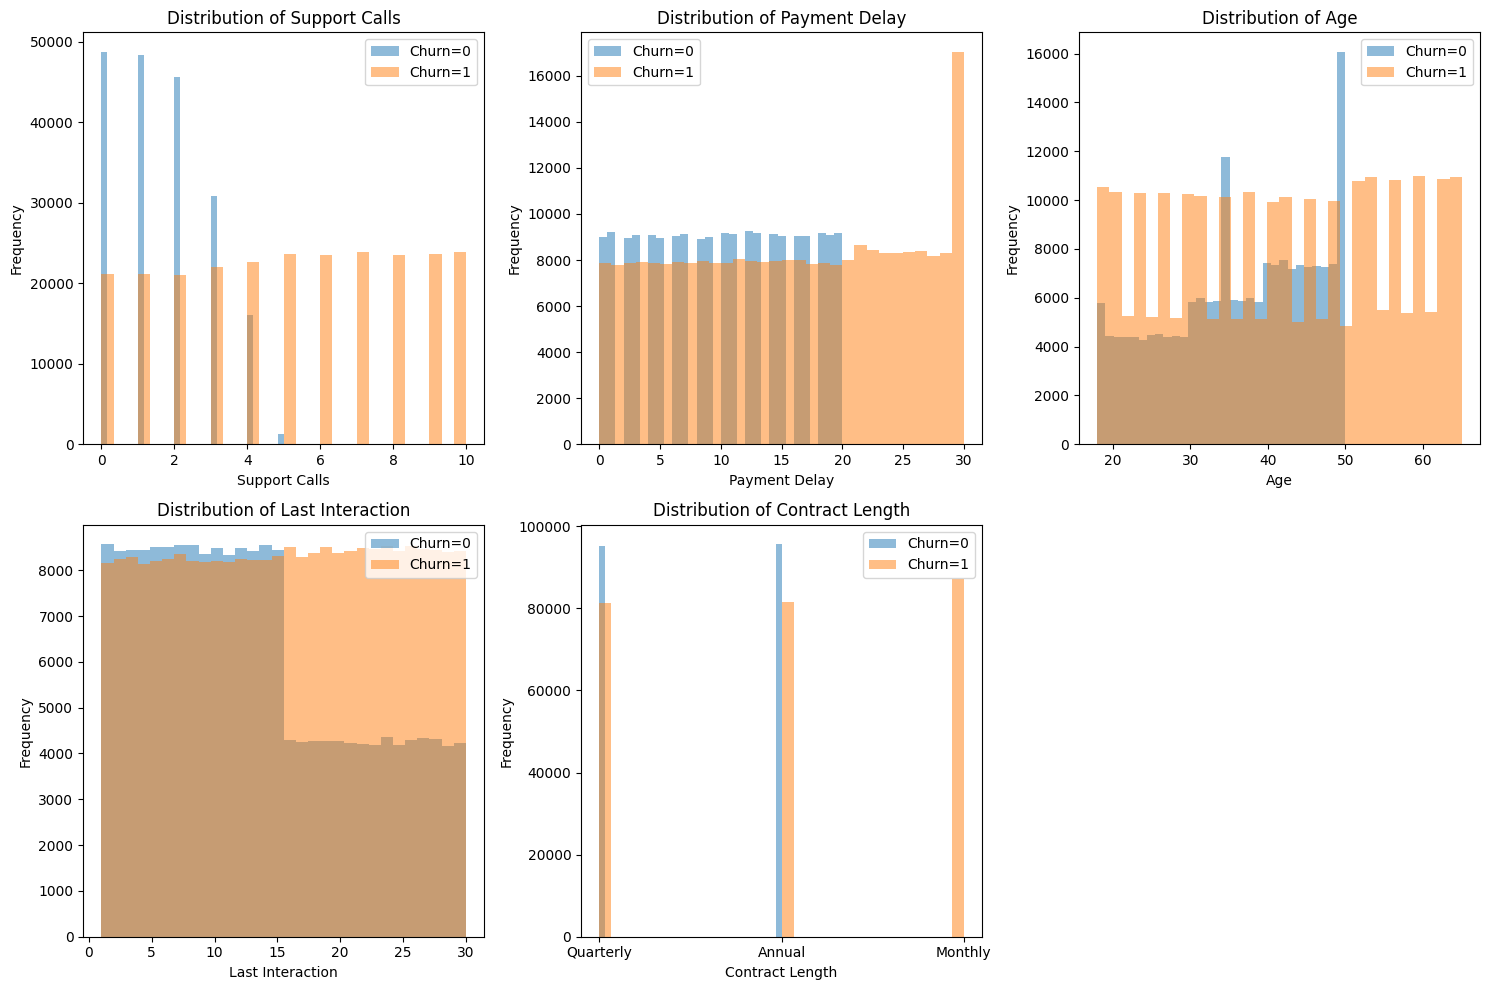


=== Comparison between Train and Test ===
Age: Train=39.37, Test=41.97, Diff=6.6%
Tenure: Train=31.26, Test=31.99, Diff=2.4%
Usage Frequency: Train=15.81, Test=15.08, Diff=4.6%
Support Calls: Train=3.60, Test=5.40, Diff=49.8%
Payment Delay: Train=12.97, Test=17.13, Diff=32.1%
Total Spend: Train=631.62, Test=541.02, Diff=14.3%
Last Interaction: Train=14.48, Test=15.50, Diff=7.0%
Churn: Train=0.57, Test=0.47, Diff=16.5%

Train unique customers: 440833
Test unique customers: 64374
Common customers (potential leakage): 62995

⚠️ WARNING: Potential data leakage detected!
Some customers appear in both train and test sets.

Stats for common customers in train:
  Count: 62995
  Churn rate: 0.979


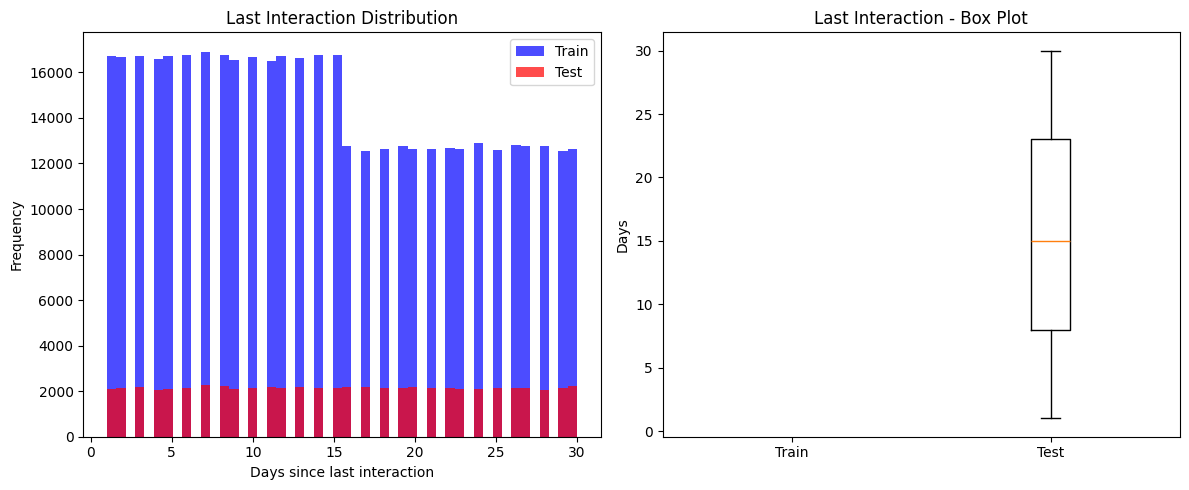


T-test for Last Interaction: t=-28.049, p=0.000
  → Significant difference between train and test (p < 0.05)

RECOMMENDATIONS FOR PIPELINE IMPROVEMENT:
1. ⚠️ REMOVE DATA LEAKAGE:
   - Remove CustomerID from features
   - Ensure no customer appears in both train and test

2. 🔧 ADDRESS IMBALANCED DATA:
   - Current churn rate: 0.567
   - Use class_weight='balanced' in models
   - Consider SMOTE or undersampling

3. 📊 FEATURE ENGINEERING:
   - Create interaction terms carefully
   - Avoid creating features that cause overfitting
   - Use feature selection to remove noisy features

4. 🎯 MODEL REGULARIZATION:
   - Reduce model complexity (limit tree depth)
   - Use cross-validation with more folds
   - Implement early stopping for gradient boosting

5. 📈 EVALUATION METRICS:
   - Focus on ROC AUC and F1 score (not just accuracy)
   - Use stratified sampling for validation
   - Track precision-recall tradeoff


In [1]:
# %% [markdown]
# # Analyse EDA des données Churn
# 
# Ce notebook analyse les données pour comprendre le surapprentissage.



# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# %%
# Charger les données
train_df = pd.read_csv('../data/customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('../data/customer_churn_dataset-testing-master.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()}")

# %%
# Vérifier les valeurs manquantes
print("Missing values in train:")
print(train_df.isnull().sum())
print("\nMissing values in test:")
print(test_df.isnull().sum())

# %%
# Distribution de la target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Train Data - Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

test_df['Churn'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'red'])
axes[1].set_title('Test Data - Churn Distribution')
axes[1].set_xlabel('Churn')

plt.tight_layout()
plt.show()

# %%
# Statistiques descriptives
print("Train data statistics:")
print(train_df.describe())

# %%
# Vérifier la corrélation entre features
# Encoder les catégories pour la corrélation
train_encoded = train_df.copy()
le = LabelEncoder()
categorical_cols = train_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    train_encoded[col] = le.fit_transform(train_encoded[col].astype(str))

# Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = train_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# %%
# Analyser la corrélation avec Churn
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)
print("Correlation with Churn:")
print(churn_correlation)

# %%
# Distribution des features importantes
important_features = churn_correlation.index[1:6]  # Top 5 sauf Churn lui-même

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    if feature in train_df.columns:
        for churn_value in [0, 1]:
            subset = train_df[train_df['Churn'] == churn_value]
            axes[i].hist(subset[feature], alpha=0.5, label=f'Churn={churn_value}', bins=30)
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()

# Supprimer les axes inutilisés
for i in range(len(important_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# %%
# Analyser les différences entre train et test
print("\n=== Comparison between Train and Test ===")

# Distributions statistiques
for col in train_df.select_dtypes(include=[np.number]).columns:
    if col != 'CustomerID':
        train_mean = train_df[col].mean()
        test_mean = test_df[col].mean()
        diff_pct = abs(train_mean - test_mean) / train_mean * 100
        print(f"{col}: Train={train_mean:.2f}, Test={test_mean:.2f}, Diff={diff_pct:.1f}%")

# %%
# Détecter les fuites de données (data leakage)
# Vérifier si CustomerID est présent dans les deux datasets
train_ids = set(train_df['CustomerID'].unique())
test_ids = set(test_df['CustomerID'].unique())
common_ids = train_ids.intersection(test_ids)

print(f"\nTrain unique customers: {len(train_ids)}")
print(f"Test unique customers: {len(test_ids)}")
print(f"Common customers (potential leakage): {len(common_ids)}")

if len(common_ids) > 0:
    print("\n⚠️ WARNING: Potential data leakage detected!")
    print("Some customers appear in both train and test sets.")
    
    # Analyser ces clients
    common_df = train_df[train_df['CustomerID'].isin(common_ids)]
    print(f"\nStats for common customers in train:")
    print(f"  Count: {len(common_df)}")
    print(f"  Churn rate: {common_df['Churn'].mean():.3f}")

# %%
# Vérifier la séparation temporelle
if 'Last Interaction' in train_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].hist(train_df['Last Interaction'], bins=50, alpha=0.7, label='Train', color='blue')
    axes[0].hist(test_df['Last Interaction'], bins=50, alpha=0.7, label='Test', color='red')
    axes[0].set_title('Last Interaction Distribution')
    axes[0].set_xlabel('Days since last interaction')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    
    # Box plot
    data_to_plot = [train_df['Last Interaction'], test_df['Last Interaction']]
    axes[1].boxplot(data_to_plot, labels=['Train', 'Test'])
    axes[1].set_title('Last Interaction - Box Plot')
    axes[1].set_ylabel('Days')
    
    plt.tight_layout()
    plt.show()
    
    # Test statistique
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(train_df['Last Interaction'].dropna(), 
                                     test_df['Last Interaction'].dropna())
    print(f"\nT-test for Last Interaction: t={t_stat:.3f}, p={p_value:.3f}")
    if p_value < 0.05:
        print("  → Significant difference between train and test (p < 0.05)")

# %%
# Recommandations pour le pipeline
print("\n" + "="*50)
print("RECOMMENDATIONS FOR PIPELINE IMPROVEMENT:")
print("="*50)

if len(common_ids) > 0:
    print("1. ⚠️ REMOVE DATA LEAKAGE:")
    print("   - Remove CustomerID from features")
    print("   - Ensure no customer appears in both train and test")

print("\n2. 🔧 ADDRESS IMBALANCED DATA:")
print(f"   - Current churn rate: {train_df['Churn'].mean():.3f}")
print("   - Use class_weight='balanced' in models")
print("   - Consider SMOTE or undersampling")

print("\n3. 📊 FEATURE ENGINEERING:")
print("   - Create interaction terms carefully")
print("   - Avoid creating features that cause overfitting")
print("   - Use feature selection to remove noisy features")

print("\n4. 🎯 MODEL REGULARIZATION:")
print("   - Reduce model complexity (limit tree depth)")
print("   - Use cross-validation with more folds")
print("   - Implement early stopping for gradient boosting")

print("\n5. 📈 EVALUATION METRICS:")
print("   - Focus on ROC AUC and F1 score (not just accuracy)")
print("   - Use stratified sampling for validation")
print("   - Track precision-recall tradeoff")